In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
#Install the required libraries


pip install -q opencv-python numpy pandas matplotlib scikit-learn torchvision

In [ ]:
#Connect Google Drive

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Check the new datasets folder

import os

DATASET_PATH = "/content/drive/MyDrive/datasets"

print("Dataset exists:", os.path.exists(DATASET_PATH))

if os.path.exists(DATASET_PATH):
    print("\nContents:")
    print(os.listdir(DATASET_PATH))

Dataset exists: True

Contents:
['CLEAR', 'DROP', 'NET SHOT', 'DRIVE', 'SMASH']


In [ ]:
#Count all videos inside the nested folders

import os

classes = [
    "SMASH",
    "CLEAR",
    "NET SHOT",
    "DROP",
    "DRIVE"
]

video_extensions = (".mp4", ".avi", ".mov", ".mkv")

print("VIDEO COUNT")
print("=" * 40)

total = 0

for class_name in classes:
    class_folder = os.path.join(DATASET_PATH, class_name)

    videos = []

    for root, dirs, files in os.walk(class_folder):
        for file in files:
            if file.lower().endswith(video_extensions):
                videos.append(os.path.join(root, file))

    print(f"{class_name}: {len(videos)} videos")
    total += len(videos)

print("=" * 40)
print(f"TOTAL: {total} videos")

VIDEO COUNT
SMASH: 500 videos
CLEAR: 500 videos
NET SHOT: 500 videos
DROP: 500 videos
DRIVE: 460 videos
TOTAL: 2460 videos


In [ ]:
# Check the FPS, total frames, and duration of one badminton video

import cv2

video_path = train_paths[0]

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

duration = total_frames / fps if fps > 0 else 0

cap.release()

print("Video:", video_path)
print("FPS:", fps)
print("Total frames:", total_frames)
print("Duration:", duration, "seconds")

Video: /content/drive/MyDrive/datasets/DRIVE/MATCH30_SHOT0288_HITFRAME00092473/DRIVE_MATCH30_SHOT0288_HITFRAME00092473.mp4
FPS: 30.0
Total frames: 16
Duration: 0.5333333333333333 seconds


In [ ]:
#Create the class mapping

CLASS_MAP = {
    "SMASH": 0,
    "CLEAR": 1,
    "NET SHOT": 2,
    "DROP": 3,
    "DRIVE": 4
}

CLASS_NAMES = [
    "Smash",
    "Clear",
    "Net Shot",
    "Drop",
    "Drive"
]

NUM_CLASSES = 5

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Classes: ['Smash', 'Clear', 'Net Shot', 'Drop', 'Drive']
Number of classes: 5


In [ ]:
#Build the complete video list

video_paths = []
labels = []

for class_name, label in CLASS_MAP.items():

    class_folder = os.path.join(DATASET_PATH, class_name)

    for root, dirs, files in os.walk(class_folder):

        for file in files:

            if file.lower().endswith(video_extensions):

                video_paths.append(
                    os.path.join(root, file)
                )

                labels.append(label)

print("DATASET SUMMARY")
print("=" * 40)
print("Total videos:", len(video_paths))
print("Total labels:", len(labels))

print("\nClass distribution:")

for class_name, label in CLASS_MAP.items():
    count = labels.count(label)
    print(f"{class_name}: {count}")

DATASET SUMMARY
Total videos: 2460
Total labels: 2460

Class distribution:
SMASH: 500
CLEAR: 500
NET SHOT: 500
DROP: 500
DRIVE: 460


In [ ]:
#Create the train/validation/test split

from sklearn.model_selection import train_test_split

# 70% training, 30% temporary
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

# Split remaining 30% equally:
# 15% validation + 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("DATASET SPLIT")
print("=" * 40)
print(f"Training:   {len(train_paths)}")
print(f"Validation: {len(val_paths)}")
print(f"Testing:    {len(test_paths)}")

print("\nClass distribution:")

for class_name, label in CLASS_MAP.items():
    print(
        f"{class_name}: "
        f"Train={train_labels.count(label)}, "
        f"Val={val_labels.count(label)}, "
        f"Test={test_labels.count(label)}"
    )

DATASET SPLIT
Training:   1722
Validation: 369
Testing:    369

Class distribution:
SMASH: Train=350, Val=75, Test=75
CLEAR: Train=350, Val=75, Test=75
NET SHOT: Train=350, Val=75, Test=75
DROP: Train=350, Val=75, Test=75
DRIVE: Train=322, Val=69, Test=69


In [ ]:
#Create the Dataset class

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class BadmintonDataset(Dataset):

    def __init__(self, video_paths, labels, num_frames=20):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, index):

        video_path = self.video_paths[index]
        label = self.labels[index]

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames <= 0:
            cap.release()
            raise RuntimeError(
                f"Could not read video: {video_path}"
            )

        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_index in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(frame_index)
            )

            success, frame = cap.read()

            if success:

                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                frame = self.transform(frame)
                frames.append(frame)

            else:

                black_frame = np.zeros(
                    (224, 224, 3),
                    dtype=np.uint8
                )

                black_frame = self.transform(
                    black_frame
                )

                frames.append(black_frame)

        cap.release()

        frames = torch.stack(frames)

        return frames, torch.tensor(
            label,
            dtype=torch.long
        )

In [ ]:
#Create the train, validation, and test datasets

NUM_FRAMES = 20

train_dataset = BadmintonDataset(
    train_paths,
    train_labels,
    num_frames=NUM_FRAMES
)

val_dataset = BadmintonDataset(
    val_paths,
    val_labels,
    num_frames=NUM_FRAMES
)

test_dataset = BadmintonDataset(
    test_paths,
    test_labels,
    num_frames=NUM_FRAMES
)

print("DATASETS CREATED")
print("=" * 40)
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples:    {len(test_dataset)}")

DATASETS CREATED
Training samples:   1722
Validation samples: 369
Testing samples:    369


In [ ]:
# Increase the batch size to 8 to reduce the number of training batches

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Batch size: 8
Training batches: 216
Validation batches: 47
Testing batches: 47


In [ ]:
#Test one batch

videos, labels_batch = next(iter(train_loader))

print("BATCH CHECK")
print("=" * 40)
print("Video shape:", videos.shape)
print("Label shape:", labels_batch.shape)
print("Labels:", labels_batch)

BATCH CHECK
Video shape: torch.Size([8, 20, 3, 224, 224])
Label shape: torch.Size([8])
Labels: tensor([2, 0, 1, 4, 0, 2, 1, 4])


In [ ]:
#Build the CNN-LSTM model

import torch
import torch.nn as nn
from torchvision import models


class CNNLSTM(nn.Module):

    def __init__(self, num_classes=5, hidden_size=256, num_layers=2):
        super().__init__()

        # Pretrained ResNet-18 CNN
        self.cnn = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Remove ResNet's final classification layer
        self.cnn.fc = nn.Identity()

        # Freeze CNN parameters
        for param in self.cnn.parameters():
            param.requires_grad = False

        # LSTM for temporal information
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        # 5-class classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):

        batch_size, num_frames, C, H, W = x.shape

        # Process all frames through CNN
        x = x.view(
            batch_size * num_frames,
            C,
            H,
            W
        )

        features = self.cnn(x)

        # Convert back to video sequences
        features = features.view(
            batch_size,
            num_frames,
            512
        )

        # Learn temporal movement
        lstm_out, _ = self.lstm(features)

        # Use the final time step
        last_output = lstm_out[:, -1, :]

        # Predict shot class
        output = self.classifier(last_output)

        return output

In [ ]:
# Move the CNN-LSTM model to the GPU and check that it produces the correct output shape

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNLSTM(
    num_classes=NUM_CLASSES,
    hidden_size=256,
    num_layers=2
)

model = model.to(device)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Test one batch
sample_videos, sample_labels = next(iter(train_loader))

sample_videos = sample_videos.to(device)

with torch.no_grad():
    sample_output = model(sample_videos)

print("Input shape:", sample_videos.shape)
print("Output shape:", sample_output.shape)

Device: cuda
GPU: Tesla T4
Input shape: torch.Size([8, 20, 3, 224, 224])
Output shape: torch.Size([8, 5])


In [ ]:
# Set up the loss function and optimizer that will be used to train the CNN-LSTM model

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# Train the CNN-LSTM model for 10 epochs and measure the training time for each epoch

from sklearn.metrics import accuracy_score, f1_score
import time

NUM_EPOCHS = 1

best_val_f1 = 0.0

for epoch in range(NUM_EPOCHS):

    epoch_start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_predictions = []
    train_targets = []
    train_loss = 0.0

    for videos, labels in train_loader:

        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(videos)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        train_predictions.extend(predictions.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)

    train_accuracy = accuracy_score(
        train_targets,
        train_predictions
    )

    train_f1 = f1_score(
        train_targets,
        train_predictions,
        average="weighted"
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_predictions = []
    val_targets = []
    val_loss = 0.0

    with torch.no_grad():

        for videos, labels in val_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            val_predictions.extend(predictions.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_accuracy = accuracy_score(
        val_targets,
        val_predictions
    )

    val_f1 = f1_score(
        val_targets,
        val_predictions,
        average="weighted"
    )

    epoch_time = time.time() - epoch_start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Time: {epoch_time/60:.2f} min"
    )

    # Save the best model
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/best_badminton_cnn_lstm.pth"
        )

        print("✅ Best model saved!")

Epoch [1/11] Train Loss: 1.2619 | Train Acc: 0.4384 | Train F1: 0.4172 | Val Loss: 1.0105 | Val Acc: 0.5230 | Val F1: 0.4679 | Time: 43.49 min
✅ Best model saved!
Epoch [2/11] Train Loss: 1.0209 | Train Acc: 0.5482 | Train F1: 0.5310 | Val Loss: 0.9740 | Val Acc: 0.5583 | Val F1: 0.5047 | Time: 14.89 min
✅ Best model saved!
Epoch [3/11] Train Loss: 0.9328 | Train Acc: 0.5633 | Train F1: 0.5523 | Val Loss: 0.9568 | Val Acc: 0.5501 | Val F1: 0.5141 | Time: 14.94 min
✅ Best model saved!
Epoch [4/11] Train Loss: 0.9071 | Train Acc: 0.5900 | Train F1: 0.5809 | Val Loss: 0.9171 | Val Acc: 0.5827 | Val F1: 0.5688 | Time: 14.89 min
✅ Best model saved!
Epoch [5/11] Train Loss: 0.8500 | Train Acc: 0.6127 | Train F1: 0.6077 | Val Loss: 0.8738 | Val Acc: 0.6043 | Val F1: 0.5696 | Time: 14.92 min
✅ Best model saved!
Epoch [6/11] Train Loss: 0.9201 | Train Acc: 0.5790 | Train F1: 0.5727 | Val Loss: 1.1232 | Val Acc: 0.5285 | Val F1: 0.4478 | Time: 14.89 min
Epoch [7/11] Train Loss: 0.9440 | Train Ac

In [ ]:
# Load the best CNN-LSTM model saved during training

best_model_path = "/content/drive/MyDrive/best_badminton_cnn_lstm.pth"

model.load_state_dict(torch.load(best_model_path, map_location=device))

model = model.to(device)
model.eval()

print("✅ Best model loaded successfully!")
print("Model:", best_model_path)

✅ Best model loaded successfully!
Model: /content/drive/MyDrive/best_badminton_cnn_lstm.pth


In [ ]:
# Evaluate the best CNN-LSTM model on the unseen test dataset

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

test_predictions = []
test_targets = []
test_loss = 0.0

model.eval()

with torch.no_grad():
    for videos, labels in test_loader:

        videos = videos.to(device)
        labels = labels.to(device)

        outputs = model(videos)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        test_predictions.extend(predictions.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

test_loss /= len(test_loader)

test_accuracy = accuracy_score(test_targets, test_predictions)
test_precision = precision_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)
test_recall = recall_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)
test_f1 = f1_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall:", round(test_recall, 4))
print("Test F1 Score:", round(test_f1, 4))

Test Loss: 0.7082
Test Accuracy: 0.664
Test Precision: 0.7067
Test Recall: 0.664
Test F1 Score: 0.6445


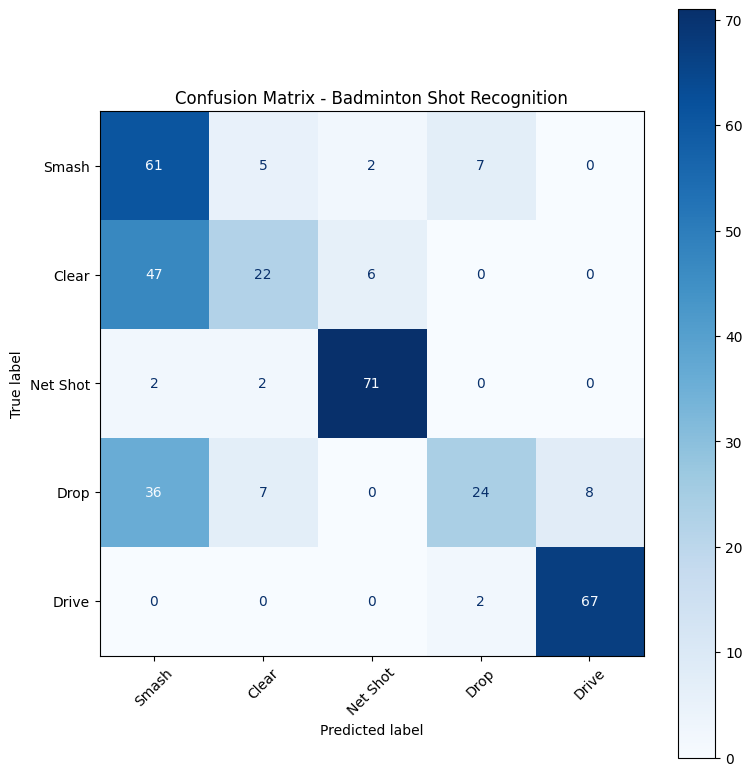

In [ ]:
# This cell generates the confusion matrix to see which badminton shots are being confused.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_targets, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Badminton Shot Recognition")
plt.tight_layout()
plt.show()

In [ ]:
# This cell generates the detailed classification report for each badminton shot class.

from sklearn.metrics import classification_report

print(classification_report(
    test_targets,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

       Smash     0.4178    0.8133    0.5520        75
       Clear     0.6111    0.2933    0.3964        75
    Net Shot     0.8987    0.9467    0.9221        75
        Drop     0.7273    0.3200    0.4444        75
       Drive     0.8933    0.9710    0.9306        69

    accuracy                         0.6640       369
   macro avg     0.7097    0.6689    0.6491       369
weighted avg     0.7067    0.6640    0.6445       369

